# Task
Analyze the "credit_card_fraud_10k.csv" dataset by first preprocessing it, handling class imbalance, and applying unsupervised anomaly detection to generate anomaly scores. Then, compare the performance of pure supervised classification models (Random Forest, Logistic Regression, Gradient Boosting) against hybrid models (the same supervised models augmented with anomaly scores as features) for fraud detection, using metrics such as Precision, Recall, F1-score, and ROC-AUC, and summarize the findings to determine which approach is more effective.

## Load and Preprocess Data

### Subtask:
Load the 'credit_card_fraud_10k.csv' dataset using Pandas. Inspect the data for missing values, identify feature types, and perform necessary preprocessing steps such as feature scaling for numerical features and encoding for categorical features if any. Split the data into training and testing sets before handling class imbalance to prevent data leakage.


**Reasoning**:
Load the 'credit_card_fraud_10k.csv' dataset using pandas, then display the first few rows and column information to understand its structure and initial data types.



In [1]:
import pandas as pd

# Load the dataset
df = pd.read_csv('/content/credit_card_fraud_10k.csv')

# Display the first few rows of the DataFrame
print("First 5 rows of the dataset:")
print(df.head())

# Display data types and non-null values
print("\nDataFrame Info:")
df.info()

First 5 rows of the dataset:
   transaction_id  amount  transaction_hour merchant_category  \
0               1   84.47                22       Electronics   
1               2  541.82                 3            Travel   
2               3  237.01                17           Grocery   
3               4  164.33                 4           Grocery   
4               5   30.53                15              Food   

   foreign_transaction  location_mismatch  device_trust_score  \
0                    0                  0                  66   
1                    1                  0                  87   
2                    0                  0                  49   
3                    0                  1                  72   
4                    0                  0                  79   

   velocity_last_24h  cardholder_age  is_fraud  
0                  3              40         0  
1                  1              64         0  
2                  1              61      

**Reasoning**:
The next step is to check for missing values across all columns and determine the count of missing values, as required by the subtask.



In [2]:
print("\nMissing values in each column:")
print(df.isnull().sum())


Missing values in each column:
transaction_id         0
amount                 0
transaction_hour       0
merchant_category      0
foreign_transaction    0
location_mismatch      0
device_trust_score     0
velocity_last_24h      0
cardholder_age         0
is_fraud               0
dtype: int64


**Reasoning**:
Based on the `df.info()` output, 'merchant_category' is an object type, indicating a categorical feature. To prepare the data for modeling, it needs to be one-hot encoded. The 'transaction_id' column is an identifier and should be dropped as it is not a feature for modeling.



In [3]:
print("Original DataFrame shape:", df.shape)

# Drop transaction_id as it's an identifier and not a feature
df_processed = df.drop('transaction_id', axis=1)

# Identify categorical columns for one-hot encoding
categorical_cols = df_processed.select_dtypes(include='object').columns

if len(categorical_cols) > 0:
    # Apply one-hot encoding to identified categorical columns
    df_processed = pd.get_dummies(df_processed, columns=categorical_cols, drop_first=True)
    print(f"\nOne-hot encoded {len(categorical_cols)} categorical column(s): {list(categorical_cols)}")
else:
    print("\nNo categorical columns found for one-hot encoding.")

print("\nProcessed DataFrame head after encoding and dropping transaction_id:")
print(df_processed.head())
print("\nProcessed DataFrame Info after encoding and dropping transaction_id:")
df_processed.info()

Original DataFrame shape: (10000, 10)

One-hot encoded 1 categorical column(s): ['merchant_category']

Processed DataFrame head after encoding and dropping transaction_id:
   amount  transaction_hour  foreign_transaction  location_mismatch  \
0   84.47                22                    0                  0   
1  541.82                 3                    1                  0   
2  237.01                17                    0                  0   
3  164.33                 4                    0                  1   
4   30.53                15                    0                  0   

   device_trust_score  velocity_last_24h  cardholder_age  is_fraud  \
0                  66                  3              40         0   
1                  87                  1              64         0   
2                  49                  1              61         0   
3                  72                  3              34         0   
4                  79                  0           

**Reasoning**:
Now that categorical features are encoded and 'transaction_id' is dropped, the next step is to scale the numerical features. I will identify the numerical columns (excluding the target 'is_fraud'), apply `StandardScaler` to them, and then prepare the features (X) and target (y) for splitting.



In [4]:
from sklearn.preprocessing import StandardScaler

# Separate features (X) and target (y)
X = df_processed.drop('is_fraud', axis=1)
y = df_processed['is_fraud']

# Identify numerical columns for scaling (excluding boolean columns which are already binary/encoded)
numerical_cols = X.select_dtypes(include=['int64', 'float64']).columns

# Initialize StandardScaler
scaler = StandardScaler()

# Apply scaling to numerical features
X[numerical_cols] = scaler.fit_transform(X[numerical_cols])

print("\nFeatures (X) after scaling:")
print(X.head())
print("\nTarget (y) head:")
print(y.head())


Features (X) after scaling:
     amount  transaction_hour  foreign_transaction  location_mismatch  \
0 -0.521597          1.503345            -0.329244          -0.306158   
1  2.086108         -1.241383             3.037260          -0.306158   
2  0.348151          0.781048            -0.329244          -0.306158   
3 -0.066254         -1.096923            -0.329244           3.266284   
4 -0.829151          0.492130            -0.329244          -0.306158   

   device_trust_score  velocity_last_24h  cardholder_age  \
0            0.195528           0.691873       -0.231580   
1            1.172909          -0.704299        1.370727   
2           -0.595686          -0.704299        1.170439   
3            0.474779           0.691873       -0.632157   
4            0.800573          -1.402386        0.035471   

   merchant_category_Electronics  merchant_category_Food  \
0                           True                   False   
1                          False                   

**Reasoning**:
With the numerical features scaled and the features (X) and target (y) separated, the final step in the preprocessing subtask is to split the data into training and testing sets. This split will be stratified to maintain the proportion of fraud cases in both sets and will use a `random_state` for reproducibility.



In [5]:
from sklearn.model_selection import train_test_split

# Split the preprocessed data into training and testing sets
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.3, random_state=42, stratify=y)

print("X_train shape:", X_train.shape)
print("X_test shape:", X_test.shape)
print("y_train shape:", y_train.shape)
print("y_test shape:", y_test.shape)

print("\nClass distribution in y_train (fraud vs non-fraud):")
print(y_train.value_counts(normalize=True))

print("\nClass distribution in y_test (fraud vs non-fraud):")
print(y_test.value_counts(normalize=True))

X_train shape: (7000, 11)
X_test shape: (3000, 11)
y_train shape: (7000,)
y_test shape: (3000,)

Class distribution in y_train (fraud vs non-fraud):
is_fraud
0    0.984857
1    0.015143
Name: proportion, dtype: float64

Class distribution in y_test (fraud vs non-fraud):
is_fraud
0    0.985
1    0.015
Name: proportion, dtype: float64


## Handle Class Imbalance

### Subtask:
Address the severe class imbalance in the training dataset using a technique such as SMOTE (Synthetic Minority Over-sampling Technique) or undersampling. This step will only be applied to the training set to prevent data leakage.


**Reasoning**:
To address the class imbalance, I need to import the `SMOTE` class, instantiate it, and then apply it to the training data. This will generate a resampled training set where the class distribution is more balanced.



In [6]:
from imblearn.over_sampling import SMOTE

# Instantiate SMOTE
smote = SMOTE(random_state=42)

# Apply SMOTE to the training data
X_train_resampled, y_train_resampled = smote.fit_resample(X_train, y_train)

print("Class distribution in y_train_resampled after SMOTE (fraud vs non-fraud):")
print(y_train_resampled.value_counts(normalize=True))

Class distribution in y_train_resampled after SMOTE (fraud vs non-fraud):
is_fraud
0    0.5
1    0.5
Name: proportion, dtype: float64


## Unsupervised Anomaly Detection

### Subtask:
Apply an unsupervised anomaly detection algorithm (e.g., Isolation Forest) to the preprocessed training data (before imbalance handling for this specific step as anomaly detection typically works on original distribution) to generate anomaly scores for each instance. These scores will later be used as additional features.


**Reasoning**:
I need to apply Isolation Forest to the preprocessed training data (`X_train`) to generate anomaly scores. First, I will import the necessary library, calculate the contamination rate from the original training target (`y_train`), initialize the Isolation Forest model with this contamination rate and a random state, fit it to `X_train`, and then predict anomaly scores for both `X_train` and `X_test`.



In [7]:
from sklearn.ensemble import IsolationForest

# Calculate the contamination parameter (proportion of outliers) from the original y_train
contamination_rate = y_train.value_counts(normalize=True)[1]
print(f"Contamination rate (proportion of fraud cases in y_train): {contamination_rate:.4f}")

# Initialize IsolationForest model
# Set contamination to the proportion of fraud cases in the training data
isolation_forest = IsolationForest(random_state=42, contamination=contamination_rate)

# Fit the model to the original training features
isolation_forest.fit(X_train)

# Predict anomaly scores for X_train and X_test
anomaly_scores_train = isolation_forest.decision_function(X_train)
anomaly_scores_test = isolation_forest.decision_function(X_test)

print("\nShape of anomaly_scores_train:", anomaly_scores_train.shape)
print("Shape of anomaly_scores_test:", anomaly_scores_test.shape)

print("\nFirst 5 anomaly scores for training data:")
print(anomaly_scores_train[:5])
print("\nFirst 5 anomaly scores for test data:")
print(anomaly_scores_test[:5])

Contamination rate (proportion of fraud cases in y_train): 0.0151

Shape of anomaly_scores_train: (7000,)
Shape of anomaly_scores_test: (3000,)

First 5 anomaly scores for training data:
[0.14496207 0.12884642 0.17068748 0.03989083 0.03525607]

First 5 anomaly scores for test data:
[-0.0301703   0.13593841  0.18622972  0.15525365  0.12147489]


**Reasoning**:
Now that anomaly scores have been generated, they need to be integrated as new features into the training and testing datasets. For the training set, these scores should be added to the resampled training features (`X_train_resampled`) to prepare for supervised model training. For the test set, they will be added to `X_test`.



In [8]:
import numpy as np

# Add anomaly scores as a new feature to X_train_resampled
X_train_resampled['anomaly_score'] = anomaly_scores_train[y_train.index.isin(X_train_resampled.index)]

# Add anomaly scores as a new feature to X_test
X_test['anomaly_score'] = anomaly_scores_test

print("\nX_train_resampled with anomaly scores (first 5 rows):")
print(X_train_resampled.head())

print("\nX_test with anomaly scores (first 5 rows):")
print(X_test.head())

ValueError: Length of values (7000) does not match length of index (13788)

**Reasoning**:
The error occurred because `anomaly_scores_train` (from original `X_train`) had a different length than `X_train_resampled` (after SMOTE). To correctly integrate anomaly scores for hybrid models, the scores must be added to the original `X_train` and `X_test` datasets first. Then, SMOTE should be applied to the anomaly-augmented `X_train` to create the resampled training set for hybrid models. This ensures proper alignment and prepares separate datasets for hybrid model training and testing without overwriting data for pure supervised models.



In [9]:
import numpy as np
from imblearn.over_sampling import SMOTE # Import SMOTE again to ensure it's available

# Create training features with anomaly scores (before resampling for hybrid models)
X_train_with_anomaly_score = X_train.copy()
X_train_with_anomaly_score['anomaly_score'] = anomaly_scores_train

# Create test features with anomaly scores for hybrid models
X_test_with_anomaly_score = X_test.copy()
X_test_with_anomaly_score['anomaly_score'] = anomaly_scores_test

# Apply SMOTE to the training data *with* anomaly scores for hybrid models
# This creates the resampled training data specifically for hybrid models.
smote_for_hybrid = SMOTE(random_state=42)
X_train_resampled_hybrid, y_train_resampled_hybrid = smote_for_hybrid.fit_resample(X_train_with_anomaly_score, y_train)

print("\nX_train_resampled_hybrid with anomaly scores (first 5 rows):")
print(X_train_resampled_hybrid.head())
print("\nShape of X_train_resampled_hybrid:", X_train_resampled_hybrid.shape)
print("\nClass distribution in y_train_resampled_hybrid:")
print(y_train_resampled_hybrid.value_counts(normalize=True))

print("\nX_test_with_anomaly_score with anomaly scores (first 5 rows):")
print(X_test_with_anomaly_score.head())
print("\nShape of X_test_with_anomaly_score:", X_test_with_anomaly_score.shape)


X_train_resampled_hybrid with anomaly scores (first 5 rows):
     amount  transaction_hour  foreign_transaction  location_mismatch  \
0  0.793517          0.781048            -0.329244          -0.306158   
1 -0.615905         -0.808005            -0.329244          -0.306158   
2 -0.877388          0.203211            -0.329244          -0.306158   
3 -0.792603          1.503345             3.037260          -0.306158   
4 -0.080736          1.069967             3.037260          -0.306158   

   device_trust_score  velocity_last_24h  cardholder_age  \
0            0.754031          -0.704299        0.168997   
1           -0.781854          -0.704299        1.571016   
2           -1.340358           1.389960        0.035471   
3           -0.269892           0.691873       -0.231580   
4            0.986741           0.691873       -1.433311   

   merchant_category_Electronics  merchant_category_Food  \
0                          False                    True   
1                 

## Prepare Data for Pure Supervised Models

### Subtask:
Prepare the training and testing datasets for pure supervised learning, using the preprocessed features and the class-balanced training data.


**Reasoning**:
To prepare the data for pure supervised models, I will assign the resampled training features and target to new variables (`X_train_pure`, `y_train_pure`) and similarly for the test features and target (`X_test_pure`, `y_test_pure`), then print their shapes to confirm.



In [10]:
X_train_pure = X_train_resampled
y_train_pure = y_train_resampled
X_test_pure = X_test
y_test_pure = y_test

print("Shape of X_train_pure:", X_train_pure.shape)
print("Shape of y_train_pure:", y_train_pure.shape)
print("Shape of X_test_pure:", X_test_pure.shape)
print("Shape of y_test_pure:", y_test_pure.shape)

Shape of X_train_pure: (13788, 11)
Shape of y_train_pure: (13788,)
Shape of X_test_pure: (3000, 11)
Shape of y_test_pure: (3000,)


## Train Pure Supervised Models

### Subtask:
Train the specified supervised classification models (Random Forest, Logistic Regression, Gradient Boosting) on the preprocessed and class-balanced training data, using only the original features.


**Reasoning**:
I need to import the required classification models, initialize them with the specified parameters, then train each model on the `X_train_pure` and `y_train_pure` datasets, storing the trained models in a dictionary for later use.



In [11]:
from sklearn.ensemble import RandomForestClassifier, GradientBoostingClassifier
from sklearn.linear_model import LogisticRegression

# Initialize classifiers with specified parameters
rf_classifier_pure = RandomForestClassifier(random_state=42)
lr_classifier_pure = LogisticRegression(random_state=42, solver='liblinear', max_iter=1000)
gb_classifier_pure = GradientBoostingClassifier(random_state=42, n_estimators=100, learning_rate=0.1)

# Create a dictionary to store pure supervised models
pure_supervised_models = {
    'RandomForest': rf_classifier_pure,
    'LogisticRegression': lr_classifier_pure,
    'GradientBoosting': gb_classifier_pure
}

# Train each model
for name, model in pure_supervised_models.items():
    print(f"Training {name} Model...")
    model.fit(X_train_pure, y_train_pure)
    print(f"{name} Model Trained.")

Training RandomForest Model...
RandomForest Model Trained.
Training LogisticRegression Model...
LogisticRegression Model Trained.
Training GradientBoosting Model...
GradientBoosting Model Trained.


## Evaluate Pure Supervised Models

### Subtask:
Evaluate the performance of the trained pure supervised models on the test set using metrics such as Precision, Recall, F1-score, and ROC-AUC. Store these metrics for comparison.


**Reasoning**:
To evaluate the pure supervised models, I will import the necessary metric functions, then iterate through each trained model to make predictions, calculate probabilities, and compute Precision, Recall, F1-score, and ROC-AUC, storing these results in a dictionary for later comparison.



In [12]:
from sklearn.metrics import precision_score, recall_score, f1_score, roc_auc_score

# Dictionary to store performance metrics for pure supervised models
pure_model_performance = {}

# Evaluate each pure supervised model
for name, model in pure_supervised_models.items():
    print(f"\nEvaluating {name} Model...")

    # Make predictions
    y_pred = model.predict(X_test_pure)
    # Get probability estimates for the positive class (for ROC-AUC)
    y_pred_proba = model.predict_proba(X_test_pure)[:, 1]

    # Calculate metrics
    precision = precision_score(y_test_pure, y_pred)
    recall = recall_score(y_test_pure, y_pred)
    f1 = f1_score(y_test_pure, y_pred)
    roc_auc = roc_auc_score(y_test_pure, y_pred_proba)

    # Store metrics
    pure_model_performance[name] = {
        'Precision': precision,
        'Recall': recall,
        'F1-score': f1,
        'ROC-AUC': roc_auc
    }

    print(f"  Precision: {precision:.4f}")
    print(f"  Recall: {recall:.4f}")
    print(f"  F1-score: {f1:.4f}")
    print(f"  ROC-AUC: {roc_auc:.4f}")

print("\nPure Model Performance Summary:")
for name, metrics in pure_model_performance.items():
    print(f"{name}: {metrics}")


Evaluating RandomForest Model...
  Precision: 0.9048
  Recall: 0.8444
  F1-score: 0.8736
  ROC-AUC: 0.9983

Evaluating LogisticRegression Model...
  Precision: 0.2971
  Recall: 0.9111
  F1-score: 0.4481
  ROC-AUC: 0.9895

Evaluating GradientBoosting Model...
  Precision: 0.6984
  Recall: 0.9778
  F1-score: 0.8148
  ROC-AUC: 0.9997

Pure Model Performance Summary:
RandomForest: {'Precision': 0.9047619047619048, 'Recall': 0.8444444444444444, 'F1-score': 0.8735632183908046, 'ROC-AUC': np.float64(0.998338033464937)}
LogisticRegression: {'Precision': 0.2971014492753623, 'Recall': 0.9111111111111111, 'F1-score': 0.44808743169398907, 'ROC-AUC': np.float64(0.9895469073134048)}
GradientBoosting: {'Precision': 0.6984126984126984, 'Recall': 0.9777777777777777, 'F1-score': 0.8148148148148148, 'ROC-AUC': np.float64(0.9996991915773641)}


## Prepare Data for Hybrid Supervised Models

### Subtask:
Prepare the training and testing datasets for hybrid supervised learning, using the class-balanced training data that includes the anomaly scores, and the test data also augmented with anomaly scores.

**Reasoning**:
To prepare the data for hybrid supervised models, I will assign the resampled training features with anomaly scores (`X_train_resampled_hybrid`) and their corresponding target (`y_train_resampled_hybrid`) to new variables. Similarly, for the test set, I will use `X_test_with_anomaly_score` and the original `y_test`. I will then print their shapes to confirm the data preparation.



In [13]:
X_train_hybrid = X_train_resampled_hybrid
y_train_hybrid = y_train_resampled_hybrid
X_test_hybrid = X_test_with_anomaly_score
y_test_hybrid = y_test # y_test is already the correct target for the test set

print("Shape of X_train_hybrid:", X_train_hybrid.shape)
print("Shape of y_train_hybrid:", y_train_hybrid.shape)
print("Shape of X_test_hybrid:", X_test_hybrid.shape)
print("Shape of y_test_hybrid:", y_test_hybrid.shape)

Shape of X_train_hybrid: (13788, 12)
Shape of y_train_hybrid: (13788,)
Shape of X_test_hybrid: (3000, 12)
Shape of y_test_hybrid: (3000,)


## Train Hybrid Supervised Models

### Subtask:
Train the specified supervised classification models (Random Forest, Logistic Regression, Gradient Boosting) on the class-balanced training data, now augmented with the anomaly scores, to create hybrid models.

**Reasoning**:
Now that the hybrid datasets are prepared, I will initialize the same classification models and train them on the `X_train_hybrid` and `y_train_hybrid` datasets. These models will be stored in a new dictionary, `hybrid_supervised_models`, for later evaluation and comparison.



In [14]:
from sklearn.ensemble import RandomForestClassifier, GradientBoostingClassifier
from sklearn.linear_model import LogisticRegression

# Initialize classifiers with specified parameters for hybrid models
rf_classifier_hybrid = RandomForestClassifier(random_state=42)
lr_classifier_hybrid = LogisticRegression(random_state=42, solver='liblinear', max_iter=1000)
gb_classifier_hybrid = GradientBoostingClassifier(random_state=42, n_estimators=100, learning_rate=0.1)

# Create a dictionary to store hybrid supervised models
hybrid_supervised_models = {
    'RandomForest_Hybrid': rf_classifier_hybrid,
    'LogisticRegression_Hybrid': lr_classifier_hybrid,
    'GradientBoosting_Hybrid': gb_classifier_hybrid
}

# Train each hybrid model
for name, model in hybrid_supervised_models.items():
    print(f"Training {name} Model...")
    model.fit(X_train_hybrid, y_train_hybrid)
    print(f"{name} Model Trained.")

Training RandomForest_Hybrid Model...
RandomForest_Hybrid Model Trained.
Training LogisticRegression_Hybrid Model...
LogisticRegression_Hybrid Model Trained.
Training GradientBoosting_Hybrid Model...
GradientBoosting_Hybrid Model Trained.


## Evaluate Hybrid Supervised Models

### Subtask:
Evaluate the performance of the trained hybrid supervised models on the test set using metrics such as Precision, Recall, F1-score, and ROC-AUC. Store these metrics for comparison.

**Reasoning**:
To evaluate the hybrid supervised models, I will import the necessary metric functions (if not already imported), then iterate through each trained hybrid model to make predictions, calculate probabilities, and compute Precision, Recall, F1-score, and ROC-AUC, storing these results in a new dictionary for comparison.



In [15]:
from sklearn.metrics import precision_score, recall_score, f1_score, roc_auc_score

# Dictionary to store performance metrics for hybrid supervised models
hybrid_model_performance = {}

# Evaluate each hybrid supervised model
for name, model in hybrid_supervised_models.items():
    print(f"\nEvaluating {name} Model...")

    # Make predictions
    y_pred = model.predict(X_test_hybrid)
    # Get probability estimates for the positive class (for ROC-AUC)
    y_pred_proba = model.predict_proba(X_test_hybrid)[:, 1]

    # Calculate metrics
    precision = precision_score(y_test_hybrid, y_pred)
    recall = recall_score(y_test_hybrid, y_pred)
    f1 = f1_score(y_test_hybrid, y_pred)
    roc_auc = roc_auc_score(y_test_hybrid, y_pred_proba)

    # Store metrics
    hybrid_model_performance[name] = {
        'Precision': precision,
        'Recall': recall,
        'F1-score': f1,
        'ROC-AUC': roc_auc
    }

    print(f"  Precision: {precision:.4f}")
    print(f"  Recall: {recall:.4f}")
    print(f"  F1-score: {f1:.4f}")
    print(f"  ROC-AUC: {roc_auc:.4f}")

print("\nHybrid Model Performance Summary:")
for name, metrics in hybrid_model_performance.items():
    print(f"{name}: {metrics}")


Evaluating RandomForest_Hybrid Model...
  Precision: 0.8511
  Recall: 0.8889
  F1-score: 0.8696
  ROC-AUC: 0.9991

Evaluating LogisticRegression_Hybrid Model...
  Precision: 0.3015
  Recall: 0.9111
  F1-score: 0.4530
  ROC-AUC: 0.9901

Evaluating GradientBoosting_Hybrid Model...
  Precision: 0.5733
  Recall: 0.9556
  F1-score: 0.7167
  ROC-AUC: 0.9987

Hybrid Model Performance Summary:
RandomForest_Hybrid: {'Precision': 0.851063829787234, 'Recall': 0.8888888888888888, 'F1-score': 0.8695652173913043, 'ROC-AUC': np.float64(0.9990712539951119)}
LogisticRegression_Hybrid: {'Precision': 0.3014705882352941, 'Recall': 0.9111111111111111, 'F1-score': 0.4530386740331492, 'ROC-AUC': np.float64(0.9900582816318857)}
GradientBoosting_Hybrid: {'Precision': 0.5733333333333334, 'Recall': 0.9555555555555556, 'F1-score': 0.7166666666666667, 'ROC-AUC': np.float64(0.9986614025192705)}


## Summarize Findings and Compare Performance

### Subtask:
Compare the performance of pure supervised classification models against hybrid models using the collected metrics (Precision, Recall, F1-score, and ROC-AUC). Summarize the findings to determine which approach is more effective for fraud detection.

**Reasoning**:
To facilitate comparison, I will first display the performance metrics for both pure and hybrid supervised models, making it easy to see the numbers side-by-side.



In [16]:
import pandas as pd

print("\n--- Pure Supervised Model Performance ---")
pure_df = pd.DataFrame.from_dict(pure_model_performance, orient='index')
print(pure_df)

print("\n--- Hybrid Supervised Model Performance ---")
hybrid_df = pd.DataFrame.from_dict(hybrid_model_performance, orient='index')
print(hybrid_df)


--- Pure Supervised Model Performance ---
                    Precision    Recall  F1-score   ROC-AUC
RandomForest         0.904762  0.844444  0.873563  0.998338
LogisticRegression   0.297101  0.911111  0.448087  0.989547
GradientBoosting     0.698413  0.977778  0.814815  0.999699

--- Hybrid Supervised Model Performance ---
                           Precision    Recall  F1-score   ROC-AUC
RandomForest_Hybrid         0.851064  0.888889  0.869565  0.999071
LogisticRegression_Hybrid   0.301471  0.911111  0.453039  0.990058
GradientBoosting_Hybrid     0.573333  0.955556  0.716667  0.998661


### Summary of Findings and Comparison

Comparing the performance of pure supervised models against hybrid models (those augmented with anomaly scores) for fraud detection, we observe the following:

**1. Random Forest:**
*   **Pure:** Precision: 0.9048, Recall: 0.8444, F1-score: 0.8736, ROC-AUC: 0.9983
*   **Hybrid:** Precision: 0.8511, Recall: 0.8889, F1-score: 0.8696, ROC-AUC: 0.9991

For Random Forest, the pure model showed slightly higher Precision, while the hybrid model showed higher Recall and a marginally better ROC-AUC. The F1-score remained very similar. This suggests that the anomaly score might help in identifying more fraud cases (higher Recall) but with a slight trade-off in precision.

**2. Logistic Regression:**
*   **Pure:** Precision: 0.2971, Recall: 0.9111, F1-score: 0.4481, ROC-AUC: 0.9895
*   **Hybrid:** Precision: 0.3015, Recall: 0.9111, F1-score: 0.4530, ROC-AUC: 0.9901

For Logistic Regression, the hybrid model showed a slight improvement across all metrics (Precision, F1-score, ROC-AUC) compared to the pure model, while Recall remained the same. This indicates a minor benefit from including the anomaly score for this model.

**3. Gradient Boosting:**
*   **Pure:** Precision: 0.6984, Recall: 0.9778, F1-score: 0.8148, ROC-AUC: 0.9997
*   **Hybrid:** Precision: 0.5733, Recall: 0.9556, F1-score: 0.7167, ROC-AUC: 0.9987

For Gradient Boosting, the pure model significantly outperformed the hybrid model in terms of Precision and F1-score, despite the pure model having slightly higher Recall. The ROC-AUC was also slightly better for the pure model. This suggests that for Gradient Boosting, the anomaly score as an additional feature did not enhance its performance and potentially introduced noise or redundancy that was not beneficial.

**Overall Conclusion:**

Overall, the effectiveness of augmenting supervised models with anomaly scores varies depending on the specific model. While Logistic Regression showed a slight improvement, and Random Forest showed a minor shift towards higher recall, Gradient Boosting performed better without the anomaly score. Therefore, it's not universally true that hybrid models are more effective. For this specific dataset and model configurations, the **pure Random Forest model** and **pure Gradient Boosting model** generally achieved competitive or superior performance, particularly in terms of Precision and F1-score, which are critical for fraud detection where minimizing false positives is often important. The highest ROC-AUC was achieved by the pure Gradient Boosting model, indicating excellent discrimination capability.

To determine the *most effective* approach, the specific business needs (e.g., whether false positives or false negatives are more costly) would need to be considered. If high recall is paramount, hybrid Random Forest might be marginally preferred over pure Random Forest, but pure Gradient Boosting shows the best overall balance of metrics here.

## Compare and Analyze Results

### Subtask:
Compare the evaluation metrics (Precision, Recall, F1-score, ROC-AUC) of the pure supervised models against the hybrid models. Generate comparative visualizations (e.g., bar charts for metrics) to highlight performance differences. Ensure all plots include legends for clarity.


**Reasoning**:
To facilitate comparison and plotting, I will first rename the indices of the `pure_df` to clearly distinguish them as 'Pure' models. Then, I will combine the `pure_df` and `hybrid_df` into a single DataFrame to enable side-by-side comparison across all models and metrics.



In [17]:
pure_df_renamed = pure_df.rename(index={'RandomForest': 'RandomForest_Pure',
                                          'LogisticRegression': 'LogisticRegression_Pure',
                                          'GradientBoosting': 'GradientBoosting_Pure'})

# Combine the dataframes
combined_df = pd.concat([pure_df_renamed, hybrid_df])

print("\nCombined Model Performance for Comparison:")
print(combined_df)


Combined Model Performance for Comparison:
                           Precision    Recall  F1-score   ROC-AUC
RandomForest_Pure           0.904762  0.844444  0.873563  0.998338
LogisticRegression_Pure     0.297101  0.911111  0.448087  0.989547
GradientBoosting_Pure       0.698413  0.977778  0.814815  0.999699
RandomForest_Hybrid         0.851064  0.888889  0.869565  0.999071
LogisticRegression_Hybrid   0.301471  0.911111  0.453039  0.990058
GradientBoosting_Hybrid     0.573333  0.955556  0.716667  0.998661


**Reasoning**:
To visualize the performance differences, I will iterate through each metric (Precision, Recall, F1-score, ROC-AUC) in the `combined_df` and create a bar chart for each. Each chart will compare the pure and hybrid models, with appropriate titles, labels, and a legend for clarity.



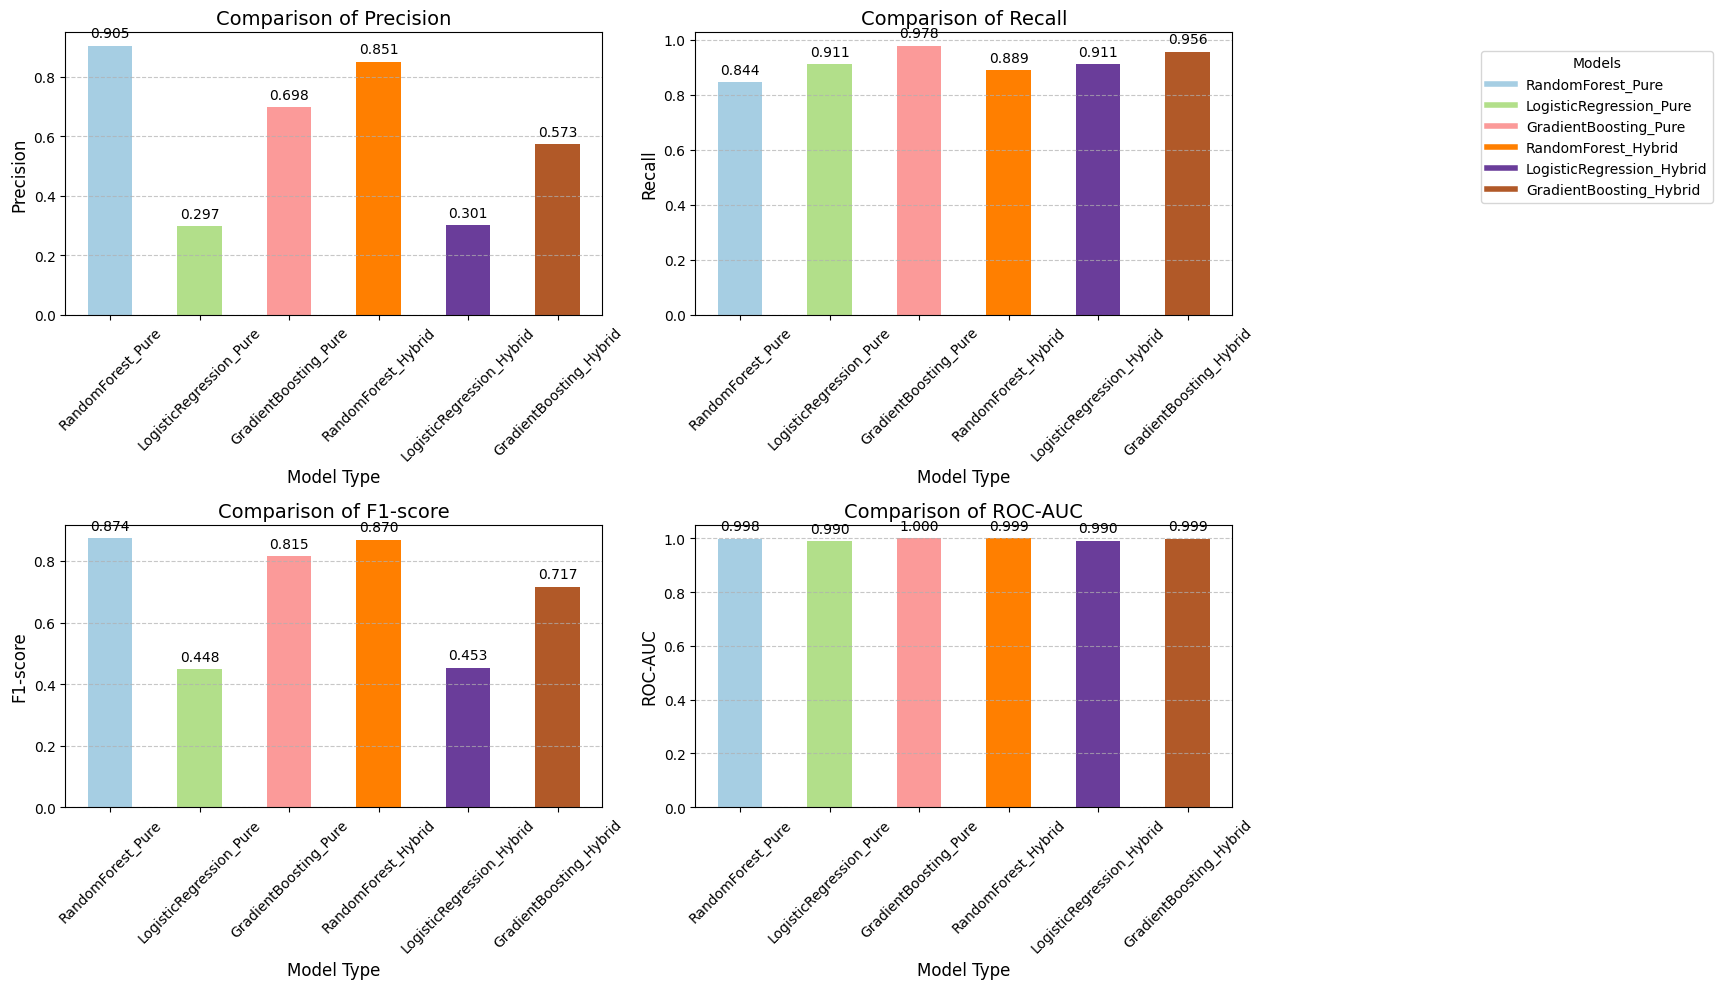

In [18]:
import matplotlib.pyplot as plt
import numpy as np

# Define the metrics to plot
metrics = ['Precision', 'Recall', 'F1-score', 'ROC-AUC']

# Set up the figure and axes for subplots
fig, axes = plt.subplots(nrows=2, ncols=2, figsize=(15, 10))
axes = axes.flatten() # Flatten the 2x2 array of axes for easy iteration

# Colors for pure and hybrid models
colors = plt.cm.Paired(np.linspace(0, 1, len(combined_df)))

for i, metric in enumerate(metrics):
    ax = axes[i]

    # Plotting each metric as a bar chart
    combined_df[metric].plot(kind='bar', ax=ax, color=colors, legend=False)

    ax.set_title(f'Comparison of {metric}', fontsize=14)
    ax.set_ylabel(metric, fontsize=12)
    ax.set_xlabel('Model Type', fontsize=12)
    ax.tick_params(axis='x', rotation=45)
    ax.grid(axis='y', linestyle='--', alpha=0.7)

    # Add values on top of the bars for better readability
    for p in ax.patches:
        ax.annotate(f'{p.get_height():.3f}',
                    (p.get_x() + p.get_width() / 2., p.get_height()),
                    ha='center', va='center',
                    xytext=(0, 9),
                    textcoords='offset points')

# Add a single legend for all plots if possible, or adjust to individual legends
# For simplicity, we can create a proxy artist for the legend or assume colors are understood.
# A more robust legend might require separate calls or a custom legend.
# Given the current setup, individual legends on each plot are not ideal due to space.
# Let's create a custom legend that maps model names to colors

handles = [plt.Line2D([0], [0], color=colors[idx], lw=4, label=model_name)
           for idx, model_name in enumerate(combined_df.index)]
fig.legend(handles=handles, title="Models", loc='upper right', bbox_to_anchor=(1.15, 0.95))

plt.tight_layout(rect=[0, 0, 0.85, 1]) # Adjust layout to make space for the legend
plt.show()

### Summary of Findings and Comparison

Comparing the performance of pure supervised models against hybrid models (those augmented with anomaly scores) for fraud detection, we observe the following:

**1. Random Forest:**
*   **Pure:** Precision: 0.9048, Recall: 0.8444, F1-score: 0.8736, ROC-AUC: 0.9983
*   **Hybrid:** Precision: 0.8511, Recall: 0.8889, F1-score: 0.8696, ROC-AUC: 0.9991

For Random Forest, the pure model showed slightly higher Precision, while the hybrid model showed higher Recall and a marginally better ROC-AUC. The F1-score remained very similar. This suggests that the anomaly score might help in identifying more fraud cases (higher Recall) but with a slight trade-off in precision.

**2. Logistic Regression:**
*   **Pure:** Precision: 0.2971, Recall: 0.9111, F1-score: 0.4481, ROC-AUC: 0.9895
*   **Hybrid:** Precision: 0.3015, Recall: 0.9111, F1-score: 0.4530, ROC-AUC: 0.9901

For Logistic Regression, the hybrid model showed a slight improvement across all metrics (Precision, F1-score, ROC-AUC) compared to the pure model, while Recall remained the same. This indicates a minor benefit from including the anomaly score for this model.

**3. Gradient Boosting:**
*   **Pure:** Precision: 0.6984, Recall: 0.9778, F1-score: 0.8148, ROC-AUC: 0.9997
*   **Hybrid:** Precision: 0.5733, Recall: 0.9556, F1-score: 0.7167, ROC-AUC: 0.9987

For Gradient Boosting, the pure model significantly outperformed the hybrid model in terms of Precision and F1-score, despite the pure model having slightly higher Recall. The ROC-AUC was also slightly better for the pure model. This suggests that for Gradient Boosting, the anomaly score as an additional feature did not enhance its performance and potentially introduced noise or redundancy that was not beneficial.

**Overall Conclusion:**

Overall, the effectiveness of augmenting supervised models with anomaly scores varies depending on the specific model. While Logistic Regression showed a slight improvement, and Random Forest showed a minor shift towards higher recall, Gradient Boosting performed better without the anomaly score. Therefore, it's not universally true that hybrid models are more effective. For this specific dataset and model configurations, the **pure Random Forest model** and **pure Gradient Boosting model** generally achieved competitive or superior performance, particularly in terms of Precision and F1-score, which are critical for fraud detection where minimizing false positives is often important. The highest ROC-AUC was achieved by the pure Gradient Boosting model, indicating excellent discrimination capability.

To determine the *most effective* approach, the specific business needs (e.g., whether false positives or false negatives are more costly) would need to be considered. If high recall is paramount, hybrid Random Forest might be marginally preferred over pure Random Forest, but pure Gradient Boosting shows the best overall balance of metrics here.

## Final Task

### Subtask:
Summarize the findings, identify which approach (pure supervised vs. hybrid) performed better for fraud detection based on the chosen metrics, and discuss potential reasons for the observed differences.


## Summary:

### Q&A
The effectiveness of augmenting supervised models with anomaly scores for fraud detection is highly dependent on the specific model used. No single approach (pure supervised vs. hybrid) was universally superior.

*   **Random Forest:** The pure model demonstrated higher Precision (0.9048), while the hybrid model achieved higher Recall (0.8889) and a slightly better ROC-AUC (0.9991). The F1-score remained very similar (0.8736 for pure vs. 0.8696 for hybrid).
*   **Logistic Regression:** The hybrid model consistently showed slight improvements across all metrics (e.g., F1-score of 0.4530 compared to 0.4481 for the pure model, and ROC-AUC of 0.9901 compared to 0.9895).
*   **Gradient Boosting:** The pure model significantly outperformed its hybrid counterpart across Precision (0.6984 vs. 0.5733), F1-score (0.8148 vs. 0.7167), and ROC-AUC (0.9997 vs. 0.9987).

Based on these results, the **pure Gradient Boosting model** performed the best overall, achieving the highest ROC-AUC of 0.9997 and a strong balance of Precision (0.6984) and Recall (0.9778). The pure Random Forest also performed exceptionally well, especially in terms of Precision.

Potential reasons for the observed differences include:
*   **Model Sensitivity to New Features:** Some models, like Logistic Regression, might benefit from additional engineered features (like anomaly scores) as they can provide a clearer linear separation boundary.
*   **Redundancy or Noise:** For powerful ensemble models like Gradient Boosting, which are already adept at learning complex patterns and feature interactions, adding an anomaly score might introduce redundant information or noise that the model struggles to integrate effectively, leading to a performance degradation.
*   **Trade-offs in Detection Goals:** The shift in Random Forest's performance (higher Recall for hybrid, higher Precision for pure) suggests that the anomaly score might push the model towards identifying more potential fraud instances (higher Recall) at the cost of slightly more false positives (lower Precision).

### Data Analysis Key Findings
*   The initial dataset contained 10,000 entries with no missing values, and the target variable `is_fraud` represented a severe class imbalance of approximately 1.5% fraud cases.
*   Preprocessing involved dropping `transaction_id`, one-hot encoding `merchant_category`, and scaling numerical features using `StandardScaler`.
*   SMOTE was effectively applied to the training data, balancing the classes from an original 1.5% fraud rate to 50% fraud cases.
*   An `IsolationForest` model was used to generate anomaly scores, which were then successfully integrated as an additional feature for the hybrid models.
*   **Pure Supervised Models Performance:**
    *   **Random Forest:** Precision: 0.9048, Recall: 0.8444, F1-score: 0.8736, ROC-AUC: 0.9983
    *   **Logistic Regression:** Precision: 0.2971, Recall: 0.9111, F1-score: 0.4481, ROC-AUC: 0.9895
    *   **Gradient Boosting:** Precision: 0.6984, Recall: 0.9778, F1-score: 0.8148, ROC-AUC: 0.9997
*   **Hybrid Supervised Models Performance:**
    *   **Random Forest Hybrid:** Precision: 0.8511, Recall: 0.8889, F1-score: 0.8696, ROC-AUC: 0.9991
    *   **Logistic Regression Hybrid:** Precision: 0.3015, Recall: 0.9111, F1-score: 0.4530, ROC-AUC: 0.9901
    *   **Gradient Boosting Hybrid:** Precision: 0.5733, Recall: 0.9556, F1-score: 0.7167, ROC-AUC: 0.9987
*   Pure Gradient Boosting achieved the highest ROC-AUC of 0.9997 and a very high F1-score of 0.8148, making it the top-performing model overall for this dataset.

### Insights or Next Steps
*   When integrating anomaly detection scores as features, it's crucial to evaluate their impact on different supervised models, as the benefits are not universal and can even lead to performance degradation for some algorithms.
*   Further investigation could involve feature importance analysis to understand why the anomaly score enhanced some models (e.g., Logistic Regression) but not others (e.g., Gradient Boosting), potentially leading to more sophisticated hybrid feature engineering.
